# The Deutsch-Jozsa Algorithm

## Quantum parallelism and its limits

In [2]:
# Load the Qiskit Runtime Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load the Runtime Primitives and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Load saved Credentials
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)
print(backend.name)

sampler = Sampler(mode=backend)

ibm_torino


The cell below will allow to switch between using the simulator or real hardware throughout the notebook.

In [3]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2

# Load the Aer Simulator and generate a noise model based on the currently-selected backend
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Alternatively, load a fake backend with generic properties and define a simulator.

noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

Now that we've loaded the necessary packages, we can proceed with the Qiskit patterns workflow. In the mapping step below, we first make function that selects among the four possible functions taking a single bit to another single bit.

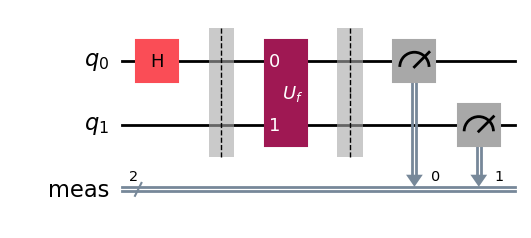

In [4]:
# Step 1: Map

from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

def twobit_function(case: int):
    """
    Generate a valid two-bit function as a `QuantumCircuit`.
    """
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")
    
    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

# first, convert oracle circuit (above) to a single gate for drawing purposes. otherwise, the circuit is too large to display
blackbox = twobit_function(3).to_gate()  # you may edit the number inside "twobit_function()" to select among the four valid functions
blackbox.label = "$U_f$"

qc.h(0)
qc.barrier()
qc.compose(blackbox, inplace=True)
qc.measure_all()

qc.draw("mpl")


Next we need to optimize and transpile the circuit to be run on the quantum computer:

In [5]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

Finally, we execute our transpiled circuit on the quantum computer and visualize our results:

In [6]:
# Step 3: Run the job on a real quantum computer

# job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc_isa], shots=1)
res = job.result()
counts = res[0].data.meas.get_counts()

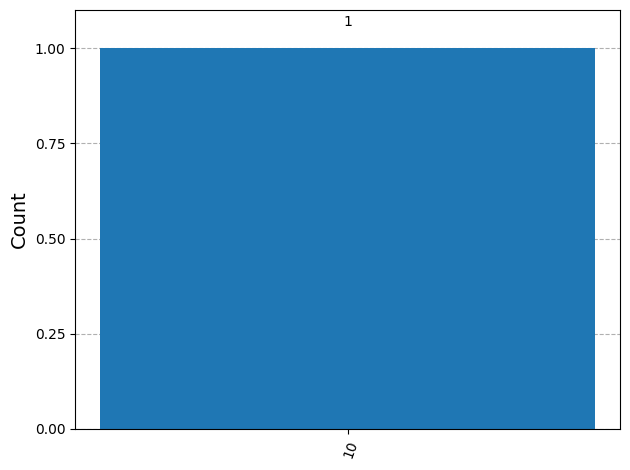

In [7]:
# Step 4: Visualize and analyze results

## Analysis
from qiskit.visualization import plot_histogram

plot_histogram(counts)

The above is a histogram of our results. Depending on the number of shots you chose to run the circuit in step 3 above, you could see one or two bars, representing the measured states of the two qubits in each shot. As always with Qiskit and in this notebook, we use "little endian" notation, meaning the states of qubits 0 through n are written in ascending order from right to left, so qubit 0 is always farthest right.

## The Deutsch algorithm

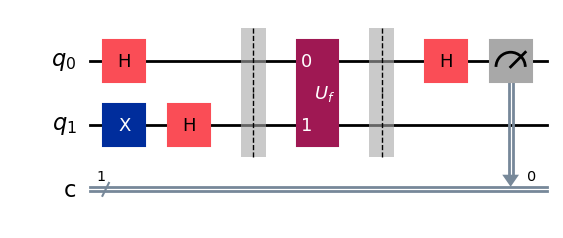

In [49]:
## Deutsch's Algorithm:

## Step 1: Map the Problem

blackbox = twobit_function(3).to_gate()
blackbox.label = ("$U_f$")

qc_deutsch = QuantumCircuit(2, 1)

qc_deutsch.x(1)
qc_deutsch.h(range(2))

qc_deutsch.barrier()
qc_deutsch.compose(blackbox, inplace=True)
qc_deutsch.barrier()

qc_deutsch.h(0)
qc_deutsch.measure(0, 0)

qc_deutsch.draw("mpl")

In [50]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

traget = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_deutsch)

In [51]:
# Run the Job on a real quantum computer

# job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc_isa], shots=1)
res = job.result()
counts = res[0].data.c.get_counts()


In [52]:
# Step 4: Visualize and analyze results

## Analysis
print(counts)
if "1" in counts:
    print("balanced")
else: 
    print("constant")

{'1': 1}
balanced


## The Deutsch-Jozsa algorithm

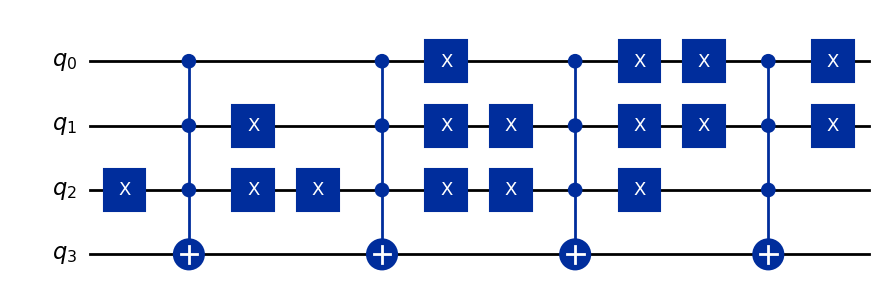

In [53]:
from qiskit import QuantumCircuit
import numpy as np


def dj_function(num_qubits):
    """
    Create a random Deutsch-Jozsa function.
    """

    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2):
        # Flip output qubits with 50% chance
        qc_dj.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance.
        return qc_dj
    
    # If the "if" statement above was "TRUE" then we've returned the constant
    # function and the function is complete. If not, we proceed in creating our
    # balanced function. Everything below is to produce the balanced function:

    # Select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits), # numbers to sample from
        2**num_qubits // 2, # numbers of Samples
        replace=False, # makes sure states are only sampled once
    )

    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj
    
    for state in on_states:
        # qc_dj.barrier()  # Barriers are added to help visualize how the functions are created. They can safely be removed.
        qc_dj = add_cx(qc_dj, f"{state:0b}")
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
        qc_dj = add_cx(qc_dj, f"{state:0b}")

    # qc_dj.barrier()

    return qc_dj

n = 3 # number of input qubits

oracle = dj_function(n)

display(oracle.draw("mpl"))

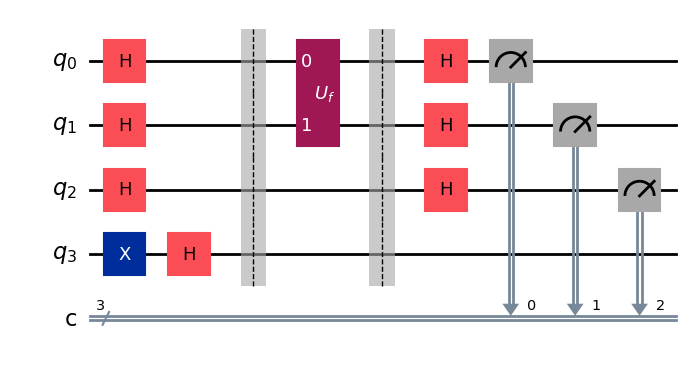

In [54]:
blackbox_for_dj = oracle.to_gate()
blackbox_for_dj.label = "$U_f$"


qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(blackbox, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

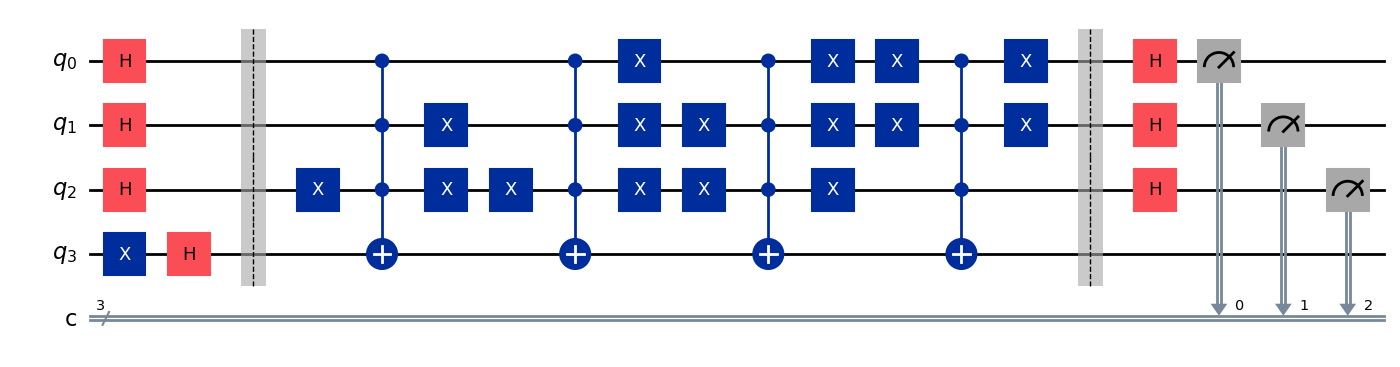

In [55]:
# Step 1: Map the problem

qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(oracle, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

In [56]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_dj)

In [57]:
# Step 3: Run the job on a real quantum computer

# job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [58]:
# Step 4: Visualize and analyze results

## Analysis
print(counts)

if (
    "0" * n in counts
):  # The D-J algorithm returns all zeroes if the function was constant
    print("constant")
else:
    print("balanced")  # anything other than all zeroes means the function is balanced.

{'010': 1}
balanced
